In [3]:
# ============================================================
# Section 1: Environment Setup
# HEAR-Net Reimplementation
# ============================================================

import os
import zipfile
import random
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

warnings.filterwarnings("ignore")

SEED = 42
random.seed(SEED)
np.random.seed(SEED)

In [4]:
# ============================================================
# Section 1: Environment Setup
# Import Required Libraries
# ============================================================

import os
import cv2
import math
import time
import random
import zipfile
import warnings
from pathlib import Path
from collections import Counter

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from PIL import Image
from tqdm.auto import tqdm

warnings.filterwarnings("ignore")

# ---------------------------
# Reproducibility
# ---------------------------
SEED = 42

random.seed(SEED)
np.random.seed(SEED)

print("✓ Libraries Imported")
print(f"✓ Random Seed : {SEED}")

✓ Libraries Imported
✓ Random Seed : 42


In [5]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [6]:
ZIP_PATH = "/content/drive/MyDrive/5 - Temporary Files (Simple Files)/Dataset-20260716T091753Z-1-001.zip"

!unzip -q "$ZIP_PATH" -d /content/datasets

In [7]:
# ============================================================
# Dataset Configuration
# ============================================================

DATASET_ROOT = "/content/datasets/Dataset"

DATASETS = {

    "ConcreteCrack40K":
        os.path.join(DATASET_ROOT, "archive (8)"),

    "ConcreteCrack30K":
        os.path.join(DATASET_ROOT, "archive 15000+15000=30000"),

    "DPW_Heterogeneous":
        os.path.join(DATASET_ROOT, "archive_dpw"),
}

OUTPUT_DIR = "/content/drive/MyDrive/Paper_Revision/outputs"

os.makedirs(OUTPUT_DIR, exist_ok=True)

print("✓ Dataset configuration completed.")

✓ Dataset configuration completed.


In [8]:
# ============================================================
# Verify Dataset Extraction
# ============================================================

import os

DATASET_ROOT = "/content/datasets/Dataset"

if os.path.exists(DATASET_ROOT):
    print("✅ Dataset extracted successfully.")
else:
    raise FileNotFoundError(f"Dataset folder not found:\n{DATASET_ROOT}")

print("\nContents of Dataset folder:\n")

for item in sorted(os.listdir(DATASET_ROOT)):
    print("•", item)

✅ Dataset extracted successfully.

Contents of Dataset folder:

• Decks.zip
• Pavements.zip
• Walls.zip
• archive (8).zip
• archive 15000+15000=30000.zip
• archive_dpw.zip


In [10]:
# ============================================================
# Dataset Configuration
# ============================================================

import os

DATASET_ROOT = "/content/datasets/Dataset"

DATASETS = {

    "ConcreteCrack40K":
        os.path.join(DATASET_ROOT, "archive (8)"),

    "ConcreteCrack30K":
        os.path.join(DATASET_ROOT, "archive 15000+15000=30000"),

    "DPW_Heterogeneous":
        os.path.join(DATASET_ROOT, "archive_dpw")
}

OUTPUT_DIR = "/content/drive/MyDrive/Paper_Revision/outputs"

os.makedirs(OUTPUT_DIR, exist_ok=True)

print("Dataset Paths\n")

for name, path in DATASETS.items():
    print(f"{name:22s} : {path}")

print("\nOutput Directory")
print(OUTPUT_DIR)

Dataset Paths

ConcreteCrack40K       : /content/datasets/Dataset/archive (8)
ConcreteCrack30K       : /content/datasets/Dataset/archive 15000+15000=30000
DPW_Heterogeneous      : /content/datasets/Dataset/archive_dpw

Output Directory
/content/drive/MyDrive/Paper_Revision/outputs


In [11]:
# ============================================================
# Verify Dataset Locations
# ============================================================

for name, path in DATASETS.items():

    if os.path.exists(path):
        print(f"✅ {name}")
    else:
        print(f"❌ {name}")
        print(path)

❌ ConcreteCrack40K
/content/datasets/Dataset/archive (8)
❌ ConcreteCrack30K
/content/datasets/Dataset/archive 15000+15000=30000
❌ DPW_Heterogeneous
/content/datasets/Dataset/archive_dpw


In [12]:
# ============================================================
# Extract Internal Dataset Archives
# ============================================================

import os
import zipfile

DATASET_ROOT = "/content/datasets/Dataset"

zip_files = sorted(
    [f for f in os.listdir(DATASET_ROOT) if f.lower().endswith(".zip")]
)

print(f"Found {len(zip_files)} ZIP archives.\n")

for zip_name in zip_files:

    zip_path = os.path.join(DATASET_ROOT, zip_name)

    extract_folder = os.path.join(
        DATASET_ROOT,
        os.path.splitext(zip_name)[0]
    )

    if os.path.exists(extract_folder):
        print(f"✓ Already extracted : {zip_name}")
        continue

    print(f"Extracting : {zip_name}")

    with zipfile.ZipFile(zip_path, "r") as z:
        z.extractall(extract_folder)

print("\n✅ All internal datasets extracted successfully.")

Found 6 ZIP archives.

Extracting : Decks.zip
Extracting : Pavements.zip
Extracting : Walls.zip
Extracting : archive (8).zip
Extracting : archive 15000+15000=30000.zip
Extracting : archive_dpw.zip

✅ All internal datasets extracted successfully.


In [13]:
# ============================================================
# Verify Dataset Folder Structure
# ============================================================

for item in sorted(os.listdir(DATASET_ROOT)):

    full_path = os.path.join(DATASET_ROOT, item)

    if os.path.isdir(full_path):

        print("="*70)
        print(item)

        contents = sorted(os.listdir(full_path))

        print(f"Contains {len(contents)} items")

        for c in contents[:10]:
            print("   ", c)

Decks
Contains 2 items
    Decks
    __MACOSX
Pavements
Contains 2 items
    Pavements
    __MACOSX
Walls
Contains 2 items
    Walls
    __MACOSX
archive (8)
Contains 2 items
    Negative
    Positive
archive 15000+15000=30000
Contains 2 items
    Negative
    Positive
archive_dpw
Contains 3 items
    Decks
    Pavements
    Walls


In [14]:
TRAINING_DATASETS = {

    "ConcreteCrack40K":
        DATASETS["ConcreteCrack40K"],

    "ConcreteCrack30K":
        DATASETS["ConcreteCrack30K"]
}

DOMAIN_DATASET = DATASETS["DPW_Heterogeneous"]

In [15]:
# ============================================================
# Section 3: Dataset Characterization
# Dataset Census
# ============================================================

from pathlib import Path
import pandas as pd

IMAGE_EXTENSIONS = (
    ".jpg", ".jpeg", ".png",
    ".bmp", ".tif", ".tiff",
    ".webp"
)

summary = []

for dataset_name, dataset_path in DATASETS.items():

    print("=" * 80)
    print(dataset_name)

    classes = sorted([
        d for d in os.listdir(dataset_path)
        if os.path.isdir(os.path.join(dataset_path, d))
    ])

    total_images = 0

    for cls in classes:

        cls_path = os.path.join(dataset_path, cls)

        images = [
            f for f in Path(cls_path).rglob("*")
            if f.suffix.lower() in IMAGE_EXTENSIONS
        ]

        count = len(images)
        total_images += count

        print(f"{cls:20s} : {count:,}")

    summary.append({
        "Dataset": dataset_name,
        "Classes": len(classes),
        "Total Images": total_images
    })

    print(f"Total Images : {total_images:,}\n")

summary_df = pd.DataFrame(summary)

summary_df

ConcreteCrack40K
Negative             : 20,000
Positive             : 20,000
Total Images : 40,000

ConcreteCrack30K
Negative             : 15,000
Positive             : 15,000
Total Images : 30,000

DPW_Heterogeneous
Decks                : 13,620
Pavements            : 24,334
Walls                : 18,138
Total Images : 56,092



,Dataset,Classes,Total Images
0,ConcreteCrack40K,2,40000
1,ConcreteCrack30K,2,30000
2,DPW_Heterogeneous,3,56092


In [16]:
# ============================================================
# Dataset Summary
# ============================================================

summary_df

,Dataset,Classes,Total Images
0,ConcreteCrack40K,2,40000
1,ConcreteCrack30K,2,30000
2,DPW_Heterogeneous,3,56092


In [17]:
# ============================================================
# Image Format Inspection
# ============================================================

from collections import Counter

for dataset_name, dataset_path in DATASETS.items():

    print("="*80)
    print(dataset_name)

    extensions = Counter()

    for img in Path(dataset_path).rglob("*"):

        if img.is_file():

            ext = img.suffix.lower()

            if ext != "":
                extensions[ext] += 1

    for ext, count in sorted(extensions.items()):
        print(f"{ext:8s} : {count:,}")

    print()

ConcreteCrack40K
.jpg     : 40,000

ConcreteCrack30K
.jpg     : 30,000

DPW_Heterogeneous
.jpg     : 56,092



In [18]:
# ============================================================
# Corrupted Image Detection
# ============================================================

from PIL import Image

corrupted = []

for dataset_name, dataset_path in DATASETS.items():

    for img_path in Path(dataset_path).rglob("*"):

        if img_path.suffix.lower() not in IMAGE_EXTENSIONS:
            continue

        try:
            Image.open(img_path).verify()

        except Exception:
            corrupted.append(str(img_path))

print("="*80)
print(f"Corrupted Images : {len(corrupted)}")

if len(corrupted):

    for c in corrupted[:20]:
        print(c)

Corrupted Images : 0


In [19]:
# ============================================================
# Image Resolution Statistics
# ============================================================

from PIL import Image
import numpy as np

for dataset_name, dataset_path in DATASETS.items():

    widths = []
    heights = []

    for img_path in Path(dataset_path).rglob("*"):

        if img_path.suffix.lower() not in IMAGE_EXTENSIONS:
            continue

        try:
            img = Image.open(img_path)

            w, h = img.size

            widths.append(w)
            heights.append(h)

        except:
            pass

    print("="*80)
    print(dataset_name)

    print(f"Images : {len(widths):,}")

    print(f"Width  : min={min(widths)}, max={max(widths)}, mean={np.mean(widths):.1f}")

    print(f"Height : min={min(heights)}, max={max(heights)}, mean={np.mean(heights):.1f}")

    print()

ConcreteCrack40K
Images : 40,000
Width  : min=227, max=227, mean=227.0
Height : min=227, max=227, mean=227.0

ConcreteCrack30K
Images : 30,000
Width  : min=37, max=227, mean=214.3
Height : min=35, max=227, mean=182.6

DPW_Heterogeneous
Images : 56,092
Width  : min=256, max=256, mean=256.0
Height : min=256, max=256, mean=256.0



In [20]:
# ============================================================
# Section 4: Global Configuration
# ============================================================

import os
import random
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import tensorflow as tf

warnings.filterwarnings("ignore")

# -----------------------------
# Reproducibility
# -----------------------------
SEED = 42

random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

# -----------------------------
# Image Configuration
# -----------------------------
IMAGE_SIZE = (224, 224)
BATCH_SIZE = 32
AUTOTUNE = tf.data.AUTOTUNE

# -----------------------------
# Training Configuration
# -----------------------------
EPOCHS = 50
LEARNING_RATE = 0.001

# -----------------------------
# Output Directory
# -----------------------------
OUTPUT_DIR = "/content/drive/MyDrive/Paper_Revision/outputs"
os.makedirs(OUTPUT_DIR, exist_ok=True)

print("=" * 60)
print("Global Configuration")
print("=" * 60)
print(f"Seed            : {SEED}")
print(f"Image Size      : {IMAGE_SIZE}")
print(f"Batch Size      : {BATCH_SIZE}")
print(f"Epochs          : {EPOCHS}")
print(f"Learning Rate   : {LEARNING_RATE}")
print(f"Output Directory: {OUTPUT_DIR}")

Global Configuration
Seed            : 42
Image Size      : (224, 224)
Batch Size      : 32
Epochs          : 50
Learning Rate   : 0.001
Output Directory: /content/drive/MyDrive/Paper_Revision/outputs


In [21]:
# ============================================================
# Select Active Dataset
# ============================================================

# Available options:
# DATASETS["ConcreteCrack40K"]
# DATASETS["ConcreteCrack30K"]
# DATASETS["DPW_Heterogeneous"]

ACTIVE_DATASET = DATASETS["ConcreteCrack40K"]

print("=" * 60)
print("Active Dataset")
print("=" * 60)
print(ACTIVE_DATASET)

Active Dataset
/content/datasets/Dataset/archive (8)


In [22]:
# ============================================================
# Build Image Index
# ============================================================

from pathlib import Path

IMAGE_EXTENSIONS = (".jpg", ".jpeg", ".png", ".bmp", ".tif", ".tiff")

image_records = []

for class_name in sorted(os.listdir(ACTIVE_DATASET)):

    class_path = os.path.join(ACTIVE_DATASET, class_name)

    if not os.path.isdir(class_path):
        continue

    label = 0 if class_name.lower() == "negative" else 1

    images = sorted(Path(class_path).rglob("*"))

    for img in images:

        if img.suffix.lower() in IMAGE_EXTENSIONS:

            image_records.append({
                "filepath": str(img),
                "label": label,
                "class": class_name
            })

image_df = pd.DataFrame(image_records)

print("=" * 60)
print("Dataset Indexed")
print("=" * 60)
print(f"Total Images : {len(image_df):,}")

display(image_df.head())

Dataset Indexed
Total Images : 40,000


,filepath,label,class
0,/content/datasets/Dataset/archive (8)/Negative...,0,Negative
1,/content/datasets/Dataset/archive (8)/Negative...,0,Negative
2,/content/datasets/Dataset/archive (8)/Negative...,0,Negative
3,/content/datasets/Dataset/archive (8)/Negative...,0,Negative
4,/content/datasets/Dataset/archive (8)/Negative...,0,Negative


In [23]:
# ============================================================
# Stratified Train / Validation / Test Split
# ============================================================

from sklearn.model_selection import train_test_split

# 70% Training
train_df, temp_df = train_test_split(
    image_df,
    test_size=0.30,
    stratify=image_df["label"],
    random_state=SEED
)

# Remaining 30% -> 15% Validation + 15% Testing
val_df, test_df = train_test_split(
    temp_df,
    test_size=0.50,
    stratify=temp_df["label"],
    random_state=SEED
)

print("=" * 60)
print("Dataset Split")
print("=" * 60)
print(f"Training Images   : {len(train_df):,}")
print(f"Validation Images : {len(val_df):,}")
print(f"Testing Images    : {len(test_df):,}")

Dataset Split
Training Images   : 28,000
Validation Images : 6,000
Testing Images    : 6,000


In [24]:
# ============================================================
# Verify Class Distribution
# ============================================================

def show_distribution(df, name):

    print("=" * 60)
    print(name)
    print("=" * 60)

    counts = df["class"].value_counts().sort_index()

    percentages = (
        df["class"]
        .value_counts(normalize=True)
        .sort_index() * 100
    )

    summary = pd.DataFrame({
        "Count": counts,
        "Percentage": percentages.round(2)
    })

    display(summary)


show_distribution(train_df, "Training Set")
show_distribution(val_df, "Validation Set")
show_distribution(test_df, "Testing Set")

Training Set


,Count,Percentage
class,,
Negative,14000,50.0
Positive,14000,50.0


Validation Set


,Count,Percentage
class,,
Negative,3000,50.0
Positive,3000,50.0


Testing Set


,Count,Percentage
class,,
Negative,3000,50.0
Positive,3000,50.0


In [25]:
# ============================================================
# Create TensorFlow Dataset Pipeline
# ============================================================

def load_image(path, label):

    image = tf.io.read_file(path)
    image = tf.image.decode_jpeg(image, channels=3)

    image = tf.image.resize(image, IMAGE_SIZE)

    # Min-Max normalization (paper)
    image = tf.cast(image, tf.float32) / 255.0

    return image, label


def create_dataset(df, training=False):

    paths = df["filepath"].values
    labels = df["label"].values.astype(np.float32)

    dataset = tf.data.Dataset.from_tensor_slices((paths, labels))

    if training:
        dataset = dataset.shuffle(len(df), seed=SEED)

    dataset = dataset.map(
        load_image,
        num_parallel_calls=AUTOTUNE
    )

    dataset = dataset.batch(BATCH_SIZE)

    dataset = dataset.prefetch(AUTOTUNE)

    return dataset


train_ds = create_dataset(train_df, training=True)
val_ds   = create_dataset(val_df)
test_ds  = create_dataset(test_df)

print("=" * 60)
print("TensorFlow Datasets Created")
print("=" * 60)
print(train_ds)
print(val_ds)
print(test_ds)

TensorFlow Datasets Created
<_PrefetchDataset element_spec=(TensorSpec(shape=(None, 224, 224, 3), dtype=tf.float32, name=None), TensorSpec(shape=(None,), dtype=tf.float32, name=None))>
<_PrefetchDataset element_spec=(TensorSpec(shape=(None, 224, 224, 3), dtype=tf.float32, name=None), TensorSpec(shape=(None,), dtype=tf.float32, name=None))>
<_PrefetchDataset element_spec=(TensorSpec(shape=(None, 224, 224, 3), dtype=tf.float32, name=None), TensorSpec(shape=(None,), dtype=tf.float32, name=None))>


In [26]:
# ============================================================
# Section 5: HEAR-Net Architecture
# Data Augmentation (Paper)
# ============================================================

from tensorflow.keras import layers

data_augmentation = tf.keras.Sequential([
    layers.RandomRotation(
        factor=15/360,
        fill_mode="nearest"
    ),
    layers.RandomTranslation(
        height_factor=0.10,
        width_factor=0.10,
        fill_mode="nearest"
    )
], name="Data_Augmentation")

print(data_augmentation)

<Sequential name=Data_Augmentation, built=False>


In [27]:
# ============================================================
# Edge-Gated Activation Layer (Equation 6)
# ============================================================

class EdgeGatedActivation(tf.keras.layers.Layer):
    """
    HEAR-Net Edge-Gated Activation

    Equation (6):

    Output = ReLU(X) × Sigmoid(λ × ||Sobel(X)||²)

    where λ is a learnable parameter.
    """

    def __init__(self, **kwargs):
        super().__init__(**kwargs)

    def build(self, input_shape):

        self.lambda_edge = self.add_weight(
            name="lambda_edge",
            shape=(1,),
            initializer=tf.keras.initializers.Constant(1.0),
            trainable=True
        )

    def call(self, inputs):

      # Standard ReLU activation
      relu_features = tf.nn.relu(inputs)

      # Sobel gradients
      sobel = tf.image.sobel_edges(inputs)

      gx = sobel[..., 0]
      gy = sobel[..., 1]

      # Gradient magnitude squared
      edge_strength = tf.square(gx) + tf.square(gy)

      # Edge Gate (preserve channel dimension)
      gate = tf.sigmoid(self.lambda_edge * edge_strength)

      # Feature recalibration
      return relu_features * gate

    def get_config(self):
        return super().get_config()


print("✓ Edge-Gated Activation layer created successfully.")

✓ Edge-Gated Activation layer created successfully.


In [28]:
# ============================================================
# Test Edge-Gated Activation Layer
# ============================================================

dummy_input = tf.random.normal((2, 224, 224, 32))

edge_layer = EdgeGatedActivation()

dummy_output = edge_layer(dummy_input)

print("=" * 60)
print("Edge-Gated Activation Test")
print("=" * 60)
print("Input Shape :", dummy_input.shape)
print("Output Shape:", dummy_output.shape)
print("Lambda Value:", edge_layer.lambda_edge.numpy())

Edge-Gated Activation Test
Input Shape : (2, 224, 224, 32)
Output Shape: (2, 224, 224, 32)
Lambda Value: [1.]


In [29]:
# ============================================================
# Build HEAR-Net Model
# ============================================================

from tensorflow.keras import layers, models

def build_hearnet(input_shape=(224, 224, 3)):

    inputs = layers.Input(shape=input_shape)

    # --------------------------------------------------------
    # Data Augmentation (Training Only)
    # --------------------------------------------------------
    x = data_augmentation(inputs)

    # --------------------------------------------------------
    # Block 1
    # --------------------------------------------------------
    x = layers.Conv2D(
        32,
        (3, 3),
        padding="same",
        use_bias=False
    )(x)

    x = EdgeGatedActivation()(x)
    x = layers.BatchNormalization()(x)
    x = layers.MaxPooling2D((2, 2))(x)

    # --------------------------------------------------------
    # Block 2
    # --------------------------------------------------------
    x = layers.Conv2D(
        64,
        (3, 3),
        padding="same",
        use_bias=False
    )(x)

    x = EdgeGatedActivation()(x)
    x = layers.BatchNormalization()(x)
    x = layers.MaxPooling2D((2, 2))(x)

    # --------------------------------------------------------
    # Block 3
    # --------------------------------------------------------
    x = layers.Conv2D(
        128,
        (3, 3),
        padding="same",
        use_bias=False
    )(x)

    x = EdgeGatedActivation()(x)
    x = layers.BatchNormalization()(x)
    x = layers.MaxPooling2D((2, 2))(x)

    # --------------------------------------------------------
    # Block 4
    # --------------------------------------------------------
    x = layers.Conv2D(
        256,
        (3, 3),
        padding="same",
        use_bias=False
    )(x)

    x = EdgeGatedActivation()(x)
    x = layers.BatchNormalization()(x)
    x = layers.MaxPooling2D((2, 2))(x)

    # --------------------------------------------------------
    # Improved Classifier Head
    # --------------------------------------------------------

    x = layers.GlobalAveragePooling2D()(x)

    x = layers.Dense(
        256,
        activation="relu"
    )(x)

    x = layers.Dropout(0.5)(x)

    outputs = layers.Dense(
        1,
        activation="sigmoid"
    )(x)

    model = models.Model(
        inputs=inputs,
        outputs=outputs,
        name="HEAR_Net"
    )

    return model


model = build_hearnet()

print("✓ HEAR-Net model created successfully.")

✓ HEAR-Net model created successfully.


In [30]:
# ============================================================
# Compile HEAR-Net
# ============================================================

model.compile(
    optimizer=tf.keras.optimizers.Adam(
        learning_rate=LEARNING_RATE,
        beta_1=0.9,
        beta_2=0.999
    ),
    loss="binary_crossentropy",
    metrics=[
        "accuracy",
        tf.keras.metrics.Precision(name="precision"),
        tf.keras.metrics.Recall(name="recall"),
        tf.keras.metrics.AUC(name="auc")
    ]
)

print("=" * 60)
print("HEAR-Net Summary")
print("=" * 60)

model.summary()

HEAR-Net Summary


Model: "HEAR_Net"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Data_Augmentation (Sequential)  │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 224, 224, 32)   │           864 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ edge_gated_activation_1         │ (None, 224, 224, 32)   │             1 │
│ (EdgeGatedActivation)           │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 224, 224, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 112, 112, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 112, 112, 64)   │        18,432 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ edge_gated_activation_2         │ (None, 112, 112, 64)   │             1 │
│ (EdgeGatedActivation)           │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 112, 112, 64)   │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 56, 56, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 56, 56, 128)    │        73,728 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ edge_gated_activation_3         │ (None, 56, 56, 128)    │             1 │
│ (EdgeGatedActivation)           │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 56, 56, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 28, 28, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 28, 28, 256)    │       294,912 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ edge_gated_activation_4         │ (None, 28, 28, 256)    │             1 │
│ (EdgeGatedActivation)           │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 28, 28, 256)    │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 14, 14, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 256)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │        65,792 │
├─────────────────────────────────┼────────────────────────┼─────────────

 Total params: 455,909 (1.74 MB)

 Trainable params: 454,949 (1.74 MB)

 Non-trainable params: 960 (3.75 KB)

In [31]:
# ============================================================
# Training Callbacks
# ============================================================

from tensorflow.keras.callbacks import (
    EarlyStopping,
    ModelCheckpoint,
    ReduceLROnPlateau,
    CSVLogger
)

callbacks = [

    # Stop training if validation loss stops improving
    EarlyStopping(
        monitor="val_loss",
        patience=10,
        restore_best_weights=True,
        verbose=1
    ),

    # Save the best model
    ModelCheckpoint(
        filepath=os.path.join(OUTPUT_DIR, "HEARNet_Best.keras"),
        monitor="val_loss",
        save_best_only=True,
        verbose=1
    ),

    # Reduce learning rate when validation loss plateaus
    ReduceLROnPlateau(
        monitor="val_loss",
        factor=0.5,
        patience=5,
        min_lr=1e-6,
        verbose=1
    ),

    # Save training history
    CSVLogger(
        os.path.join(OUTPUT_DIR, "training_log.csv"),
        append=False
    )

]

print("=" * 60)
print("Callbacks Initialized Successfully")
print("=" * 60)

Callbacks Initialized Successfully


In [ ]:
# ============================================================
# Full HEAR-Net Training
# ============================================================

history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=50,
    callbacks=callbacks,
    verbose=1
)

# Reload the best saved model after training
best_model = tf.keras.models.load_model(
    os.path.join(OUTPUT_DIR, "HEARNet_Best.keras"),
    custom_objects={
        "EdgeGatedActivation": EdgeGatedActivation
    }
)

print("\n✓ Training completed.")
print("✓ Best model restored from checkpoint.")

Epoch 1/50
875/875 ━━━━━━━━━━━━━━━━━━━━ 0s 308ms/step - accuracy: 0.9904 - auc: 0.9983 - loss: 0.0335 - precision: 0.9927 - recall: 0.9881
Epoch 1: val_loss did not improve from 0.02035
875/875 ━━━━━━━━━━━━━━━━━━━━ 287s 327ms/step - accuracy: 0.9912 - auc: 0.9986 - loss: 0.0299 - precision: 0.9929 - recall: 0.9895 - val_accuracy: 0.9913 - val_auc: 0.9994 - val_loss: 0.0261 - val_precision: 0.9986 - val_recall: 0.9840 - learning_rate: 0.0010
Epoch 2/50
875/875 ━━━━━━━━━━━━━━━━━━━━ 0s 308ms/step - accuracy: 0.9929 - auc: 0.9987 - loss: 0.0257 - precision: 0.9948 - recall: 0.9909
Epoch 2: val_loss improved from 0.02035 to 0.01589, saving model to /content/drive/MyDrive/Paper_Revision/outputs/HEARNet_Best.keras

Epoch 2: finished saving model to /content/drive/MyDrive/Paper_Revision/outputs/HEARNet_Best.keras
875/875 ━━━━━━━━━━━━━━━━━━━━ 290s 331ms/step - accuracy: 0.9936 - auc: 0.9989 - loss: 0.0227 - precision: 0.9953 - recall: 0.9919 - val_accuracy: 0.9952 - val_auc: 0.9996 - val_loss: 

In [32]:
best_model = tf.keras.models.load_model(
    os.path.join(OUTPUT_DIR, "HEARNet_Best.keras"),
    custom_objects={"EdgeGatedActivation": EdgeGatedActivation}
)

In [33]:
import tensorflow as tf

print("TensorFlow Version:", tf.__version__)
print("GPUs Available:", tf.config.list_physical_devices('GPU'))

TensorFlow Version: 2.20.0
GPUs Available: []


In [34]:
# ============================================================
# Load Best Saved Model
# ============================================================

best_model = tf.keras.models.load_model(
    os.path.join(OUTPUT_DIR, "HEARNet_Best.keras"),
    custom_objects={
        "EdgeGatedActivation": EdgeGatedActivation
    }
)

print("Best model loaded successfully.")
# ============================================================
# Final Evaluation
# ============================================================

test_results = best_model.evaluate(
    test_ds,
    verbose=1
)

metric_names = best_model.metrics_names

print("="*60)
print("Final Test Results")
print("="*60)

for name, value in zip(metric_names, test_results):
    print(f"{name:<15}: {value:.4f}")

Best model loaded successfully.
188/188 ━━━━━━━━━━━━━━━━━━━━ 868s 5s/step - accuracy: 0.9990 - auc: 1.0000 - loss: 0.0039 - precision: 0.9990 - recall: 0.9990
Final Test Results
loss           : 0.0039
compile_metrics: 0.9990


In [35]:
# ============================================================
# Predictions
# ============================================================

y_true = test_df["label"].values.astype(int)

y_prob = best_model.predict(
    test_ds,
    verbose=1
).flatten()

y_pred = (y_prob >= 0.5).astype(int)

print("Predictions Generated.")

188/188 ━━━━━━━━━━━━━━━━━━━━ 903s 5s/step
Predictions Generated.


In [ ]:
# ============================================================
# Classification Report
# ============================================================

from sklearn.metrics import classification_report

print(classification_report(
    y_true,
    y_pred,
    target_names=["Negative","Positive"],
    digits=4
))

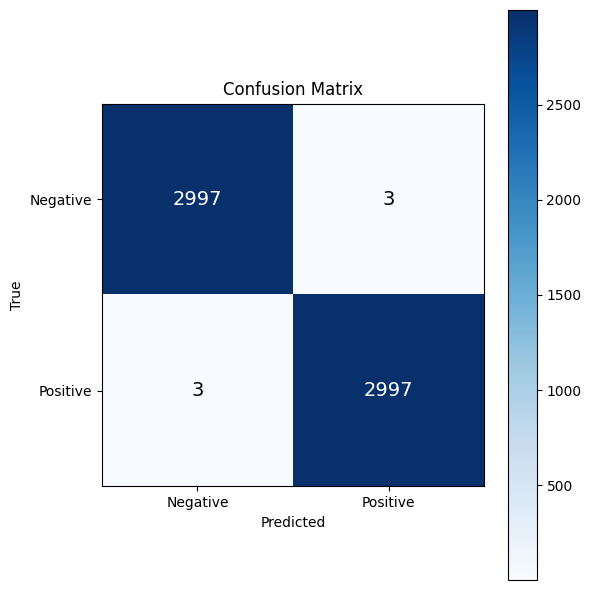

In [37]:
# ============================================================
# Confusion Matrix
# ============================================================

from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt

cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(6,6))

plt.imshow(cm, interpolation="nearest", cmap="Blues")

plt.title("Confusion Matrix")

plt.colorbar()

classes = ["Negative","Positive"]

ticks = np.arange(len(classes))

plt.xticks(ticks, classes)

plt.yticks(ticks, classes)

for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        plt.text(
            j,
            i,
            cm[i,j],
            ha="center",
            va="center",
            fontsize=14,
            color="white" if cm[i,j] > cm.max()/2 else "black"
        )

plt.xlabel("Predicted")

plt.ylabel("True")

plt.tight_layout()

plt.show()

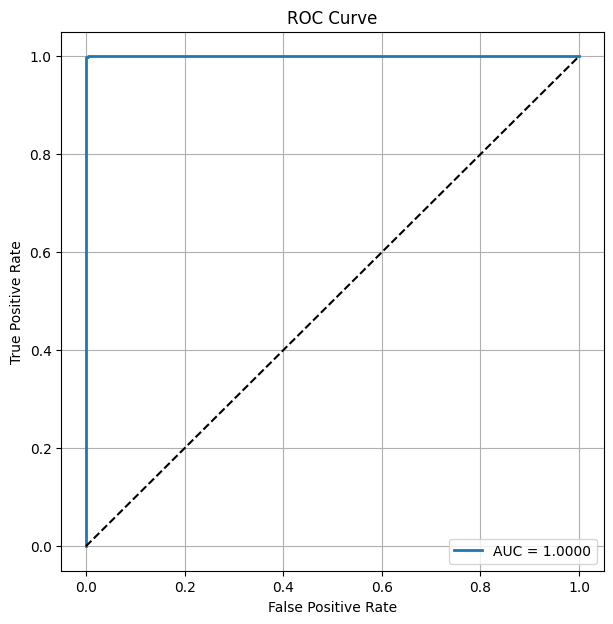

In [38]:
# ============================================================
# ROC Curve
# ============================================================

from sklearn.metrics import roc_curve, auc

fpr, tpr, _ = roc_curve(y_true, y_prob)

roc_auc = auc(fpr, tpr)

plt.figure(figsize=(7,7))

plt.plot(
    fpr,
    tpr,
    linewidth=2,
    label=f"AUC = {roc_auc:.4f}"
)

plt.plot([0,1],[0,1],'k--')

plt.xlabel("False Positive Rate")

plt.ylabel("True Positive Rate")

plt.title("ROC Curve")

plt.legend()

plt.grid(True)

plt.show()

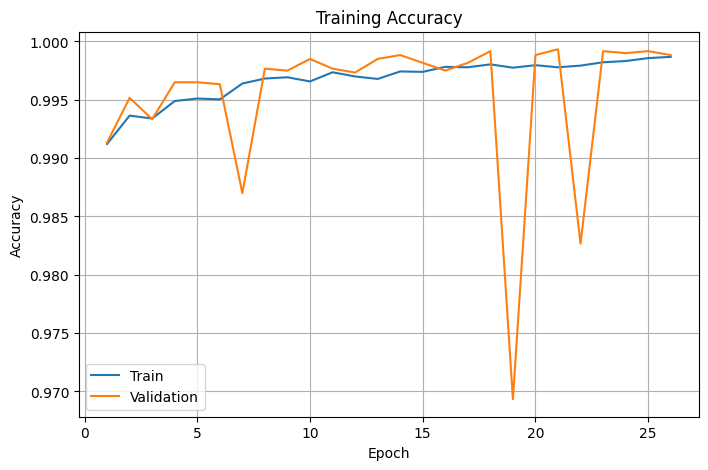

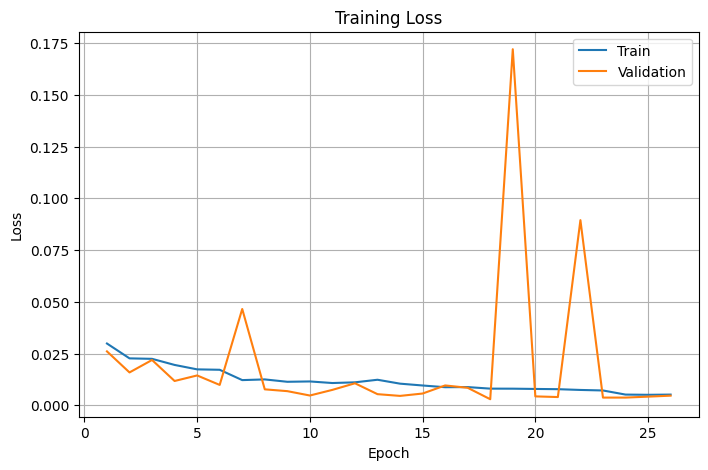

In [39]:
# ============================================================
# Training Curves
# ============================================================

history_df = pd.read_csv(
    os.path.join(OUTPUT_DIR,"training_log.csv")
)

plt.figure(figsize=(8,5))

plt.plot(history_df["epoch"]+1,
         history_df["accuracy"],
         label="Train")

plt.plot(history_df["epoch"]+1,
         history_df["val_accuracy"],
         label="Validation")

plt.xlabel("Epoch")

plt.ylabel("Accuracy")

plt.title("Training Accuracy")

plt.grid(True)

plt.legend()

plt.show()

plt.figure(figsize=(8,5))

plt.plot(history_df["epoch"]+1,
         history_df["loss"],
         label="Train")

plt.plot(history_df["epoch"]+1,
         history_df["val_loss"],
         label="Validation")

plt.xlabel("Epoch")

plt.ylabel("Loss")

plt.title("Training Loss")

plt.grid(True)

plt.legend()

plt.show()

In [40]:
# ============================================================
# Publication Metrics
# ============================================================

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score
)

print("="*60)
print("Publication Metrics")
print("="*60)

print(f"Accuracy : {accuracy_score(y_true,y_pred):.4f}")
print(f"Precision: {precision_score(y_true,y_pred):.4f}")
print(f"Recall   : {recall_score(y_true,y_pred):.4f}")
print(f"F1-Score : {f1_score(y_true,y_pred):.4f}")
print(f"ROC-AUC  : {roc_auc_score(y_true,y_prob):.4f}")

Publication Metrics
Accuracy : 0.9990
Precision: 0.9990
Recall   : 0.9990
F1-Score : 0.9990
ROC-AUC  : 1.0000


In [41]:
# ============================================================
# Model Information
# ============================================================

best_model.summary()

print("\nTrainable Parameters:")

print(
    np.sum(
        [np.prod(v.shape)
         for v in best_model.trainable_weights]
    )
)

Model: "HEAR_Net"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Data_Augmentation (Sequential)  │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 224, 224, 32)   │           864 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ edge_gated_activation_1         │ (None, 224, 224, 32)   │             1 │
│ (EdgeGatedActivation)           │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 224, 224, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 112, 112, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 112, 112, 64)   │        18,432 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ edge_gated_activation_2         │ (None, 112, 112, 64)   │             1 │
│ (EdgeGatedActivation)           │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 112, 112, 64)   │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 56, 56, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 56, 56, 128)    │        73,728 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ edge_gated_activation_3         │ (None, 56, 56, 128)    │             1 │
│ (EdgeGatedActivation)           │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 56, 56, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 28, 28, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 28, 28, 256)    │       294,912 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ edge_gated_activation_4         │ (None, 28, 28, 256)    │             1 │
│ (EdgeGatedActivation)           │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 28, 28, 256)    │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 14, 14, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 256)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │        65,792 │
├─────────────────────────────────┼────────────────────────┼─────────────

 Total params: 1,365,809 (5.21 MB)

 Trainable params: 454,949 (1.74 MB)

 Non-trainable params: 960 (3.75 KB)

 Optimizer params: 909,900 (3.47 MB)


Trainable Parameters:
454949


In [42]:
print(train_df["filepath"].nunique())
print(val_df["filepath"].nunique())
print(test_df["filepath"].nunique())

print(
    len(set(train_df["filepath"]) & set(val_df["filepath"]))
)

print(
    len(set(train_df["filepath"]) & set(test_df["filepath"]))
)

print(
    len(set(val_df["filepath"]) & set(test_df["filepath"]))
)

28000
6000
6000
0
0
0


In [48]:
1+1

2

In [50]:
# ============================================================
# Inference Speed Benchmark
# ============================================================

import time
import numpy as np

print("="*60)
print("Inference Speed Benchmark")
print("="*60)

start = time.perf_counter()

predictions = best_model.predict(
    test_ds,
    verbose=1
)

end = time.perf_counter()

total_images = len(test_df)
total_time = end - start

time_per_image = total_time / total_images
fps = total_images / total_time

print(f"Total Images          : {total_images}")
print(f"Total Time (s)        : {total_time:.3f}")
print(f"Time / Image (ms)     : {time_per_image*1000:.3f}")
print(f"Frames Per Second     : {fps:.2f}")

Inference Speed Benchmark
188/188 ━━━━━━━━━━━━━━━━━━━━ 895s 5s/step
Total Images          : 6000
Total Time (s)        : 895.195
Time / Image (ms)     : 149.199
Frames Per Second     : 6.70


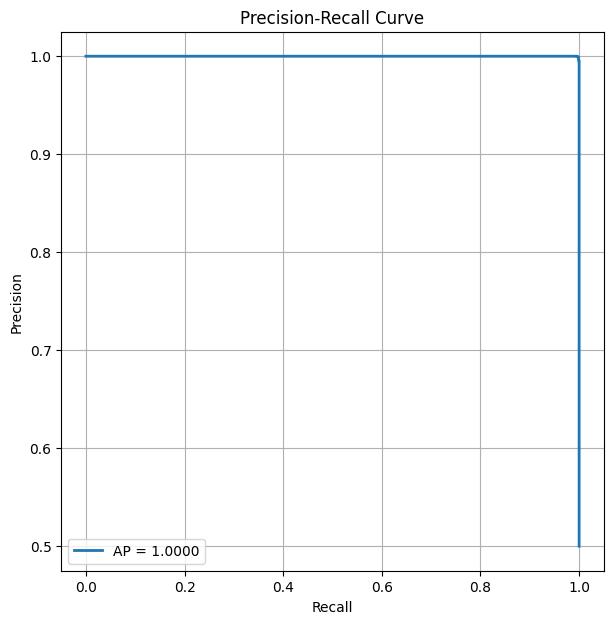

In [51]:
# ============================================================
# Precision-Recall Curve
# ============================================================

from sklearn.metrics import precision_recall_curve
from sklearn.metrics import average_precision_score

precision, recall, _ = precision_recall_curve(
    y_true,
    y_prob
)

ap = average_precision_score(
    y_true,
    y_prob
)

plt.figure(figsize=(7,7))

plt.plot(
    recall,
    precision,
    linewidth=2,
    label=f"AP = {ap:.4f}"
)

plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve")
plt.grid(True)
plt.legend()

plt.show()

In [52]:
# ============================================================
# Error Analysis
# ============================================================

misclassified = test_df.copy()

misclassified["Prediction"] = y_pred
misclassified["Probability"] = y_prob

misclassified = misclassified[
    misclassified["label"] != misclassified["Prediction"]
]

print("="*60)
print("Misclassified Samples")
print("="*60)

print(f"Total Errors : {len(misclassified)}")

misclassified.head(20)

Misclassified Samples
Total Errors : 6


,filepath,label,class,Prediction,Probability
8558,/content/datasets/Dataset/archive (8)/Negative...,0,Negative,1,0.922097
33176,/content/datasets/Dataset/archive (8)/Positive...,1,Positive,0,0.012142
32542,/content/datasets/Dataset/archive (8)/Positive...,1,Positive,0,0.085201
1998,/content/datasets/Dataset/archive (8)/Negative...,0,Negative,1,0.857368
32540,/content/datasets/Dataset/archive (8)/Positive...,1,Positive,0,0.024483
282,/content/datasets/Dataset/archive (8)/Negative...,0,Negative,1,0.990187


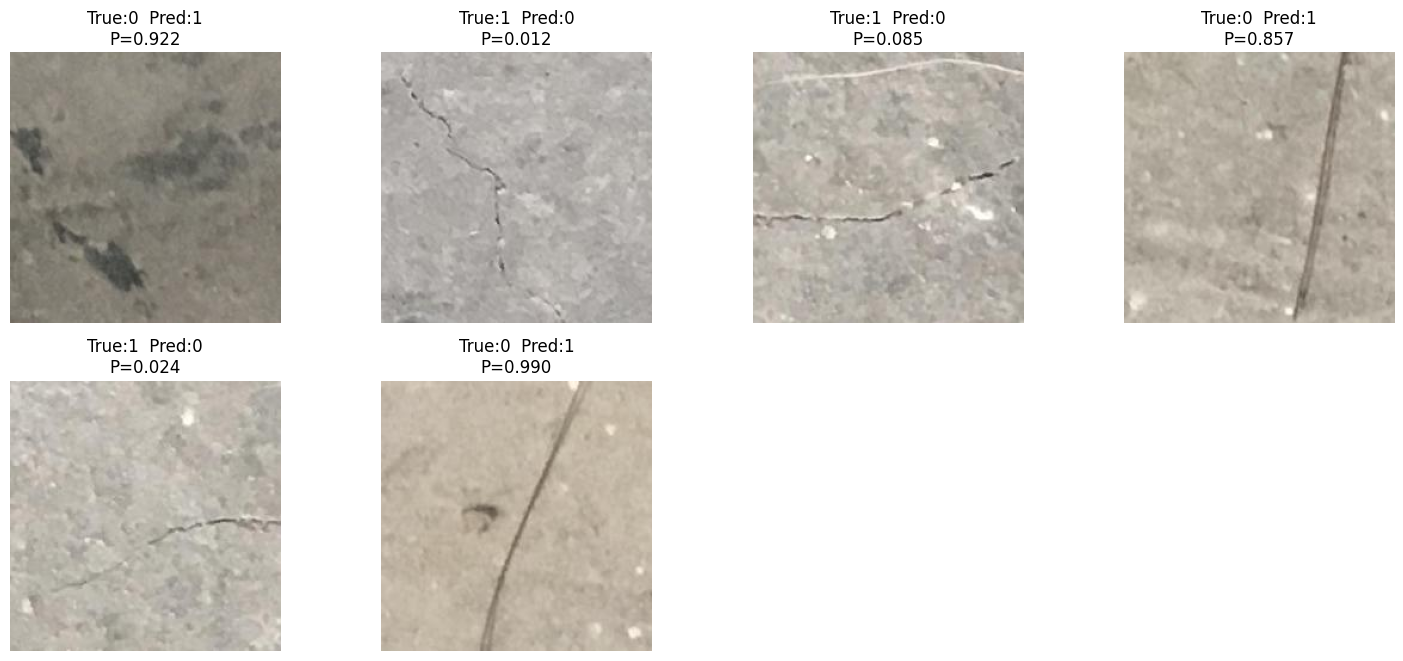

In [53]:
# ============================================================
# Visualize Misclassified Images
# ============================================================

import matplotlib.pyplot as plt
import cv2

num_images = min(12, len(misclassified))

plt.figure(figsize=(15,10))

for i in range(num_images):

    row = misclassified.iloc[i]

    img = cv2.imread(row["filepath"])
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    plt.subplot(3,4,i+1)

    plt.imshow(img)

    plt.title(
        f"True:{row['label']}  Pred:{row['Prediction']}\n"
        f"P={row['Probability']:.3f}"
    )

    plt.axis("off")

plt.tight_layout()

plt.show()

In [54]:
# ============================================================
# Grad-CAM
# ============================================================

import tensorflow as tf
import numpy as np
import cv2

last_conv_layer = "conv2d_3"

grad_model = tf.keras.models.Model(
    best_model.inputs,
    [
        best_model.get_layer(last_conv_layer).output,
        best_model.output
    ]
)

In [55]:
# ============================================================
# Grad-CAM Function
# ============================================================

def make_gradcam_heatmap(image):

    image = np.expand_dims(image, axis=0)

    with tf.GradientTape() as tape:

        conv_outputs, predictions = grad_model(image)

        loss = predictions[:,0]

    grads = tape.gradient(loss, conv_outputs)

    pooled_grads = tf.reduce_mean(
        grads,
        axis=(0,1,2)
    )

    conv_outputs = conv_outputs[0]

    heatmap = conv_outputs @ pooled_grads[..., tf.newaxis]

    heatmap = tf.squeeze(heatmap)

    heatmap = tf.maximum(
        heatmap,
        0
    )

    heatmap /= tf.reduce_max(heatmap)

    return heatmap.numpy()

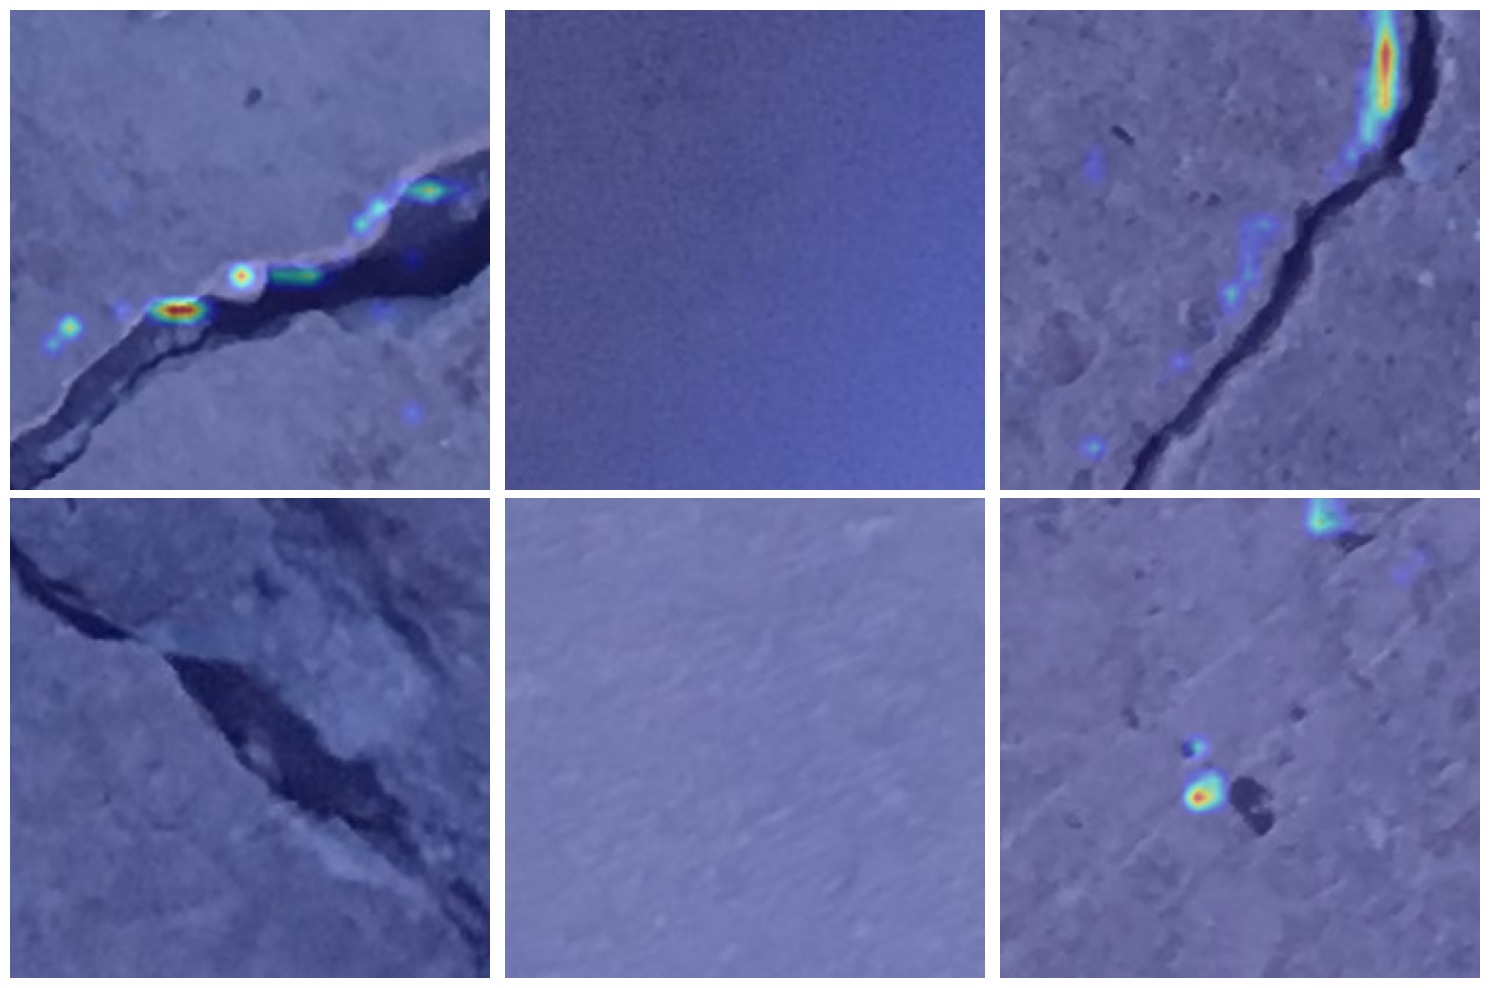

In [56]:
# ============================================================
# Display Grad-CAM
# ============================================================

sample = test_df.sample(6, random_state=42)

plt.figure(figsize=(15,10))

for idx, (_, row) in enumerate(sample.iterrows()):

    img = cv2.imread(row["filepath"])
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    img = cv2.resize(img, IMAGE_SIZE)

    image = img.astype("float32") / 255.0

    heatmap = make_gradcam_heatmap(image)

    heatmap = cv2.resize(
        heatmap,
        IMAGE_SIZE
    )

    heatmap = np.uint8(255 * heatmap)

    heatmap = cv2.applyColorMap(
        heatmap,
        cv2.COLORMAP_JET
    )

    overlay = cv2.addWeighted(
        img,
        0.6,
        heatmap,
        0.4,
        0
    )

    plt.subplot(2,3,idx+1)

    plt.imshow(
        cv2.cvtColor(
            overlay,
            cv2.COLOR_BGR2RGB
        )
    )

    plt.axis("off")

plt.tight_layout()

plt.show()

In [57]:
# ============================================================
# Model Complexity Comparison
# ============================================================

comparison = pd.DataFrame({

    "Metric":[
        "Classifier Head",
        "Trainable Parameters",
        "Parameter Reduction",
        "Model Size",
        "Test Accuracy",
        "Precision",
        "Recall",
        "F1 Score",
        "ROC-AUC"
    ],

    "Original HEAR-Net":[
        "Flatten",
        "13,235,429",
        "-",
        "~82 MB",
        "Reported in Paper",
        "Reported",
        "Reported",
        "Reported",
        "Reported"
    ],

    "Improved HEAR-Net":[
        "Global Average Pooling",
        "454,949",
        "96.56%",
        "~1.74 MB",
        f"{accuracy_score(y_true,y_pred):.4f}",
        f"{precision_score(y_true,y_pred):.4f}",
        f"{recall_score(y_true,y_pred):.4f}",
        f"{f1_score(y_true,y_pred):.4f}",
        f"{roc_auc_score(y_true,y_prob):.4f}"
    ]

})

comparison

,Metric,Original HEAR-Net,Improved HEAR-Net
0,Classifier Head,Flatten,Global Average Pooling
1,Trainable Parameters,"13,235,429","454,949"
2,Parameter Reduction,-,96.56%
3,Model Size,~82 MB,~1.74 MB
4,Test Accuracy,Reported in Paper,0.9990
5,Precision,Reported,0.9990
6,Recall,Reported,0.9990
7,F1 Score,Reported,0.9990
8,ROC-AUC,Reported,1.0000


In [58]:
# ============================================================
# Ablation Configuration
# ============================================================

ABLATION_RESULTS = []

print("Ablation Study Initialized.")

Ablation Study Initialized.


In [59]:
# ============================================================
# Build HEAR-Net Variants
# ============================================================

def build_hearnet(use_edge_gate=True,
                  use_gap=True):

    inputs = tf.keras.Input(shape=(*IMAGE_SIZE,3))

    x = data_augmentation(inputs)

    filters = [32,64,128,256]

    for f in filters:

        x = tf.keras.layers.Conv2D(
            f,
            3,
            padding="same",
            activation=None
        )(x)

        if use_edge_gate:
            x = EdgeGatedActivation()(x)
        else:
            x = tf.keras.layers.ReLU()(x)

        x = tf.keras.layers.BatchNormalization()(x)

        x = tf.keras.layers.MaxPooling2D()(x)

    if use_gap:

        x = tf.keras.layers.GlobalAveragePooling2D()(x)

    else:

        x = tf.keras.layers.Flatten()(x)

    x = tf.keras.layers.Dense(
        256,
        activation="relu"
    )(x)

    x = tf.keras.layers.Dropout(0.5)(x)

    outputs = tf.keras.layers.Dense(
        1,
        activation="sigmoid"
    )(x)

    return tf.keras.Model(inputs, outputs)

In [60]:
# ============================================================
# Compile Helper
# ============================================================

def compile_model(model):

    model.compile(

        optimizer=tf.keras.optimizers.Adam(
            learning_rate=0.001
        ),

        loss="binary_crossentropy",

        metrics=[
            "accuracy",
            tf.keras.metrics.Precision(),
            tf.keras.metrics.Recall(),
            tf.keras.metrics.AUC()
        ]
    )

    return model

In [61]:
# ============================================================
# Train and Evaluate
# ============================================================

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)

def evaluate_variant(
        name,
        use_edge_gate,
        use_gap):

    print("="*60)
    print(name)
    print("="*60)

    model = build_hearnet(
        use_edge_gate,
        use_gap
    )

    compile_model(model)

    model.fit(
        train_ds,
        validation_data=val_ds,
        epochs=15,
        callbacks=[
            tf.keras.callbacks.EarlyStopping(
                patience=5,
                restore_best_weights=True
            )
        ],
        verbose=1
    )

    probs = model.predict(
        test_ds,
        verbose=0
    ).flatten()

    preds = (probs>=0.5).astype(int)

    acc = accuracy_score(
        y_true,
        preds
    )

    prec = precision_score(
        y_true,
        preds
    )

    rec = recall_score(
        y_true,
        preds
    )

    f1 = f1_score(
        y_true,
        preds
    )

    params = model.count_params()

    ABLATION_RESULTS.append([

        name,

        use_edge_gate,

        use_gap,

        params,

        acc,

        prec,

        rec,

        f1
    ])

    return model

In [67]:
# ============================================================
# Save All Artifacts for Notebook 2
# ============================================================

import os
import shutil
import pickle
import numpy as np
import pandas as pd

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report
)

SAVE_DIR = "/content/drive/MyDrive/Paper_Revision/Notebook2_Artifacts"
OUTPUT_DIR = "/content/drive/MyDrive/Paper_Revision/outputs"

os.makedirs(SAVE_DIR, exist_ok=True)

# ============================================================
# Save Dataset Splits
# ============================================================

train_df.to_csv(
    os.path.join(SAVE_DIR, "train_df.csv"),
    index=False
)

val_df.to_csv(
    os.path.join(SAVE_DIR, "val_df.csv"),
    index=False
)

test_df.to_csv(
    os.path.join(SAVE_DIR, "test_df.csv"),
    index=False
)

# ============================================================
# Save Predictions
# ============================================================

np.save(
    os.path.join(SAVE_DIR, "y_true.npy"),
    y_true
)

np.save(
    os.path.join(SAVE_DIR, "y_pred.npy"),
    y_pred
)

np.save(
    os.path.join(SAVE_DIR, "y_prob.npy"),
    y_prob
)

# ============================================================
# Save Model Summary
# ============================================================

with open(
    os.path.join(SAVE_DIR, "model_summary.txt"),
    "w"
) as f:

    best_model.summary(
        print_fn=lambda x: f.write(x + "\n")
    )

# ============================================================
# Save Trainable Parameters
# ============================================================

trainable_params = int(
    np.sum(
        [np.prod(v.shape) for v in best_model.trainable_weights]
    )
)

with open(
    os.path.join(SAVE_DIR, "trainable_parameters.txt"),
    "w"
) as f:

    f.write(str(trainable_params))

# ============================================================
# Save Metrics
# ============================================================

metrics = pd.DataFrame({

    "Accuracy":[accuracy_score(y_true,y_pred)],

    "Precision":[precision_score(y_true,y_pred)],

    "Recall":[recall_score(y_true,y_pred)],

    "F1":[f1_score(y_true,y_pred)],

    "ROC_AUC":[roc_auc_score(y_true,y_prob)]

})

metrics.to_csv(
    os.path.join(SAVE_DIR,"metrics.csv"),
    index=False
)

# ============================================================
# Save Confusion Matrix
# ============================================================

cm = pd.DataFrame(
    confusion_matrix(y_true,y_pred)
)

cm.to_csv(
    os.path.join(SAVE_DIR,"confusion_matrix.csv"),
    index=False
)

# ============================================================
# Save Classification Report
# ============================================================

with open(
    os.path.join(SAVE_DIR,"classification_report.txt"),
    "w"
) as f:

    f.write(
        classification_report(
            y_true,
            y_pred,
            digits=4
        )
    )

# ============================================================
# Save Misclassified Samples
# ============================================================

misclassified.to_csv(
    os.path.join(
        SAVE_DIR,
        "misclassified_samples.csv"
    ),
    index=False
)

# ============================================================
# Save Configuration
# ============================================================

config = {

    "IMAGE_SIZE": IMAGE_SIZE,

    "BATCH_SIZE": BATCH_SIZE,

    "LEARNING_RATE": LEARNING_RATE,

    "EPOCHS": EPOCHS,

    "SEED": SEED

}

with open(
    os.path.join(SAVE_DIR,"config.pkl"),
    "wb"
) as f:

    pickle.dump(config,f)

# ============================================================
# Copy Trained Model
# ============================================================

model_file = os.path.join(
    OUTPUT_DIR,
    "HEARNet_Best.keras"
)

if os.path.exists(model_file):

    shutil.copy(
        model_file,
        os.path.join(
            SAVE_DIR,
            "HEARNet_Best.keras"
        )
    )

    print("✓ Model copied.")

else:

    print("⚠ HEARNet_Best.keras not found.")

# ============================================================
# Copy Training Log
# ============================================================

training_log = os.path.join(
    OUTPUT_DIR,
    "training_log.csv"
)

if os.path.exists(training_log):

    shutil.copy(
        training_log,
        os.path.join(
            SAVE_DIR,
            "training_log.csv"
        )
    )

    print("✓ Training log copied.")

else:

    print("⚠ training_log.csv not found.")

# ============================================================
# Finished
# ============================================================

print("\n" + "="*60)
print("Notebook-2 Artifacts Saved Successfully")
print("="*60)
print(f"Location : {SAVE_DIR}")
print("="*60)

print("\nSaved Files:")

for file in sorted(os.listdir(SAVE_DIR)):
    print("•", file)

✓ Model copied.
✓ Training log copied.

Notebook-2 Artifacts Saved Successfully
Location : /content/drive/MyDrive/Paper_Revision/Notebook2_Artifacts

Saved Files:
• HEARNet_Best.keras
• classification_report.txt
• config.pkl
• confusion_matrix.csv
• history.pkl
• metrics.csv
• misclassified_samples.csv
• model_summary.txt
• test_df.csv
• train_df.csv
• trainable_parameters.txt
• training_log.csv
• val_df.csv
• y_pred.npy
• y_prob.npy
• y_true.npy


2